--- UPLOAD YOUR CSV DATASET ---


Saving Mall_Customers.csv to Mall_Customers.csv


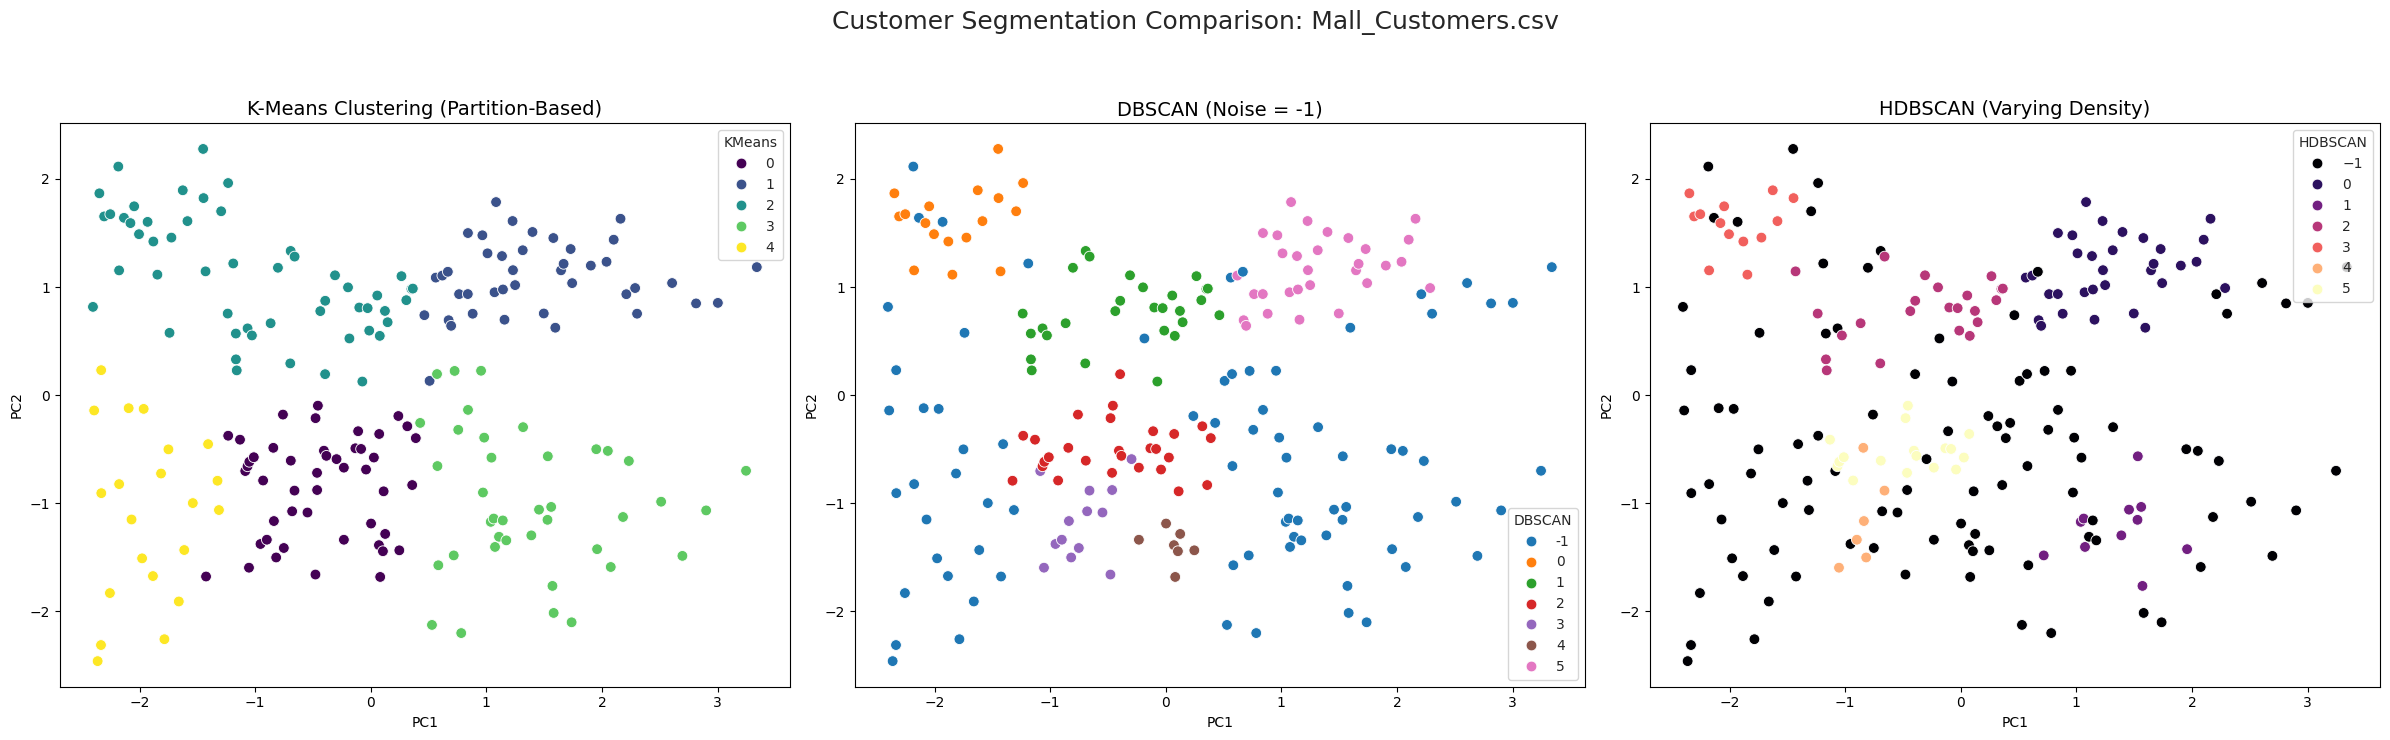


--- SUCCESS ---
Results saved to customer_segmentation_results.csv. Downloading now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# 1. INSTALLATION (Needed for HDBSCAN in Colab)
!pip install hdbscan -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import hdbscan

# --- STEP 2: DATA UPLOAD ---
print("--- UPLOAD YOUR CSV DATASET ---")
uploaded = files.upload()

# Identify the file and load it
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# --- STEP 3: PREPROCESSING ---
# We filter for numeric columns only and drop rows with missing values
numeric_df = df.select_dtypes(include=[np.number]).dropna()

# Scale the data (Standardization is mandatory for distance-based clustering)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

# --- STEP 4: DIMENSIONALITY REDUCTION (PCA) ---
# To visualize high-dimensional data in a 2D plot, we reduce it to 2 components
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

# --- STEP 5: APPLYING CLUSTERING ALGORITHMS ---

# 1. K-Means
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df['KMeans_Labels'] = kmeans.fit_predict(scaled_data)

# 2. DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Labels'] = dbscan.fit_predict(scaled_data)

# 3. HDBSCAN
hdb = hdbscan.HDBSCAN(min_cluster_size=5, gen_min_span_tree=True)
df['HDBSCAN_Labels'] = hdb.fit_predict(scaled_data)

# Attach labels to our PCA dataframe for plotting
df_pca['KMeans'] = df['KMeans_Labels']
df_pca['DBSCAN'] = df['DBSCAN_Labels']
df_pca['HDBSCAN'] = df['HDBSCAN_Labels']

# --- STEP 6: VISUALIZATION ---
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
sns.set_style("whitegrid")

# Plot 1: K-Means
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='KMeans', palette='viridis', ax=axes[0], s=60)
axes[0].set_title('K-Means Clustering (Partition-Based)', fontsize=14)

# Plot 2: DBSCAN
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='DBSCAN', palette='tab10', ax=axes[1], s=60)
axes[1].set_title('DBSCAN (Noise = -1)', fontsize=14)

# Plot 3: HDBSCAN
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='HDBSCAN', palette='magma', ax=axes[2], s=60)
axes[2].set_title('HDBSCAN (Varying Density)', fontsize=14)

plt.suptitle(f"Customer Segmentation Comparison: {file_name}", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

# --- STEP 7: EXPORT RESULTS ---
output_file = 'customer_segmentation_results.csv'
df.to_csv(output_file, index=False)
print(f"\n--- SUCCESS ---")
print(f"Results saved to {output_file}. Downloading now...")
files.download(output_file)